# Benchmark XGBoost
Biểu đồ dưới đây sẽ minh họa lý do tại sao chọn số lượng cây tối ưu.

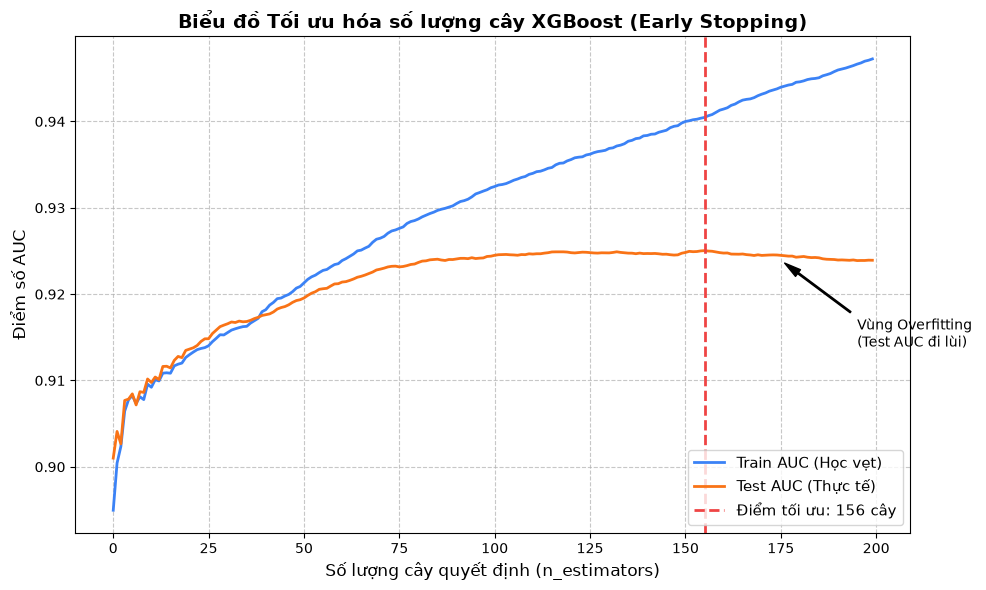

In [ ]:
import sys
import os
import matplotlib.pyplot as plt
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))

from services.ml_engine.src.machine_learning.config import get_task_config
from services.ml_engine.src.machine_learning.preprocessing import DataPreprocessor
from services.ml_engine.src.machine_learning.features import FeatureEngineer
from xgboost import XGBClassifier

# 1. Tiền xử lý dữ liệu
config = get_task_config("credit_risk")
preprocessor = DataPreprocessor(config)
df = preprocessor.clean(save=False)
X_train, X_test, y_train, y_test = preprocessor.split_data(df)

# 2. Tính WoE
feature_eng = FeatureEngineer(config)
feature_eng.build_encoder(X_train, y_train)
X_train_enc = feature_eng.transform(X_train)
X_test_enc = feature_eng.transform(X_test)

# 3. Huấn luyện XGBoost với Early Stopping
params = config.get("params", {})
params["n_estimators"] = 1000
params["learning_rate"] = 0.05
params["early_stopping_rounds"] = 50
params["eval_metric"] = "auc"
params["seed"] = 42

model = XGBClassifier(**params)
eval_set = [(X_train_enc, y_train), (X_test_enc, y_test)]

model.fit(
    X_train_enc, y_train,
    eval_set=eval_set,
    verbose=False
)

# 4. Lấy lịch sử điểm AUC từ bộ nhớ XGBoost
results = model.evals_result()
epochs = len(results['validation_0']['auc'])
x_axis = range(0, epochs)

# 5. Vẽ biểu đồ trực quan hóa
plt.figure(figsize=(10, 6))
plt.plot(x_axis, results['validation_0']['auc'], label='Train AUC (Học vẹt)', color='#3b82f6', linewidth=2)
plt.plot(x_axis, results['validation_1']['auc'], label='Test AUC (Thực tế)', color='#f97316', linewidth=2)
plt.axvline(x=model.best_iteration, color='#ef4444', linestyle='--', linewidth=2,
            label=f'Điểm tối ưu: {model.best_iteration + 1} cây')

plt.annotate('Vùng Overfitting \n(Test AUC đi lùi)', 
             xy=(model.best_iteration + 20, results['validation_1']['auc'][-1]), 
             xytext=(model.best_iteration + 40, results['validation_1']['auc'][-1] - 0.01),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=6))

plt.legend(loc='lower right', fontsize=11)
plt.ylabel('Điểm số AUC', fontsize=12)
plt.xlabel('Số lượng cây quyết định (n_estimators)', fontsize=12)
plt.title('Biểu đồ Tối ưu hóa số lượng cây XGBoost (Early Stopping)', fontsize=14, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
